# 05a: Evaluate the Single-Architecture Ensemble

B Steele, Colorado State University, ROSSyndicate — last updated Sep 16, 2026

Companion to `04a_single_arch_seed_test.ipynb`, mirroring `05_evaluate_ensemble.ipynb`'s evaluation for that experiment: assembles the 10-seed x XGBoost-only x 4-fold ensemble (40 models — the same total count as the production 5-seed x 2-algorithm ensemble), evaluates it on the same fixed holdout, and compares directly against `05`'s production numbers. This is the evaluation half of the downstream-applications question `04a` was built to test: does one algorithm with more seeds capture as much useful variability as two algorithms with fewer seeds?

## Setup

In [ ]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

sys.path.insert(0, str(Path("python").resolve()))
import features
import metrics as M
import model_xgb
import spatial_cv

AQUAMATCH_DIR = Path("aquamatch_files")
MODELS_DIR = Path("xg_models") / "04a_single_arch"
PROD_DIR = Path("xg_models") / "v3_production"
TARGET = "harmonized_value"
MOD = model_xgb
SEEDS = list(range(601, 611))

ROSS_LT_PAL = ["#002EA3", "#E70870", "#256BF5", "#745CFB", "#1E4D2B", "#56104E"]

df = pd.read_parquet(AQUAMATCH_DIR / "base_with_splits.parquet")
df = features.add_spectral_indices(df)
df = features.coarsen_site_features(df)
df = spatial_cv.build_splits(df, ensemble_seeds=SEEDS)
holdout = df[df["is_holdout"]].reset_index(drop=True)
print(f"holdout: {len(holdout):,} rows")

## Assemble the ensemble and compare against production

In [2]:
all_rows = []
for seed in SEEDS:
    all_rows.append(pd.read_parquet(MODELS_DIR / f"seed{seed}" / "holdout_predictions.parquet"))
all_preds = pd.concat(all_rows, ignore_index=True)

ensemble_pred = all_preds.groupby(["siteSR_id", "date"]).agg(
    y=("y", "first"), pred=("pred", "mean"), HUC4=("HUC4", "first"), HUC8=("HUC8", "first")).reset_index()
ensemble_metrics = M.all_metrics(ensemble_pred["y"], ensemble_pred["pred"])
print(f"04a ensemble (10 seeds x xgboost, 40 models): {ensemble_metrics}")

prod_rows = []
for seed in [501, 502, 503, 504, 505]:
    prod_rows.append(pd.read_parquet(PROD_DIR / f"seed{seed}" / "holdout_predictions.parquet"))
prod_preds = pd.concat(prod_rows, ignore_index=True)
prod_ensemble = prod_preds.groupby(["siteSR_id", "date"]).agg(y=("y", "first"), pred=("pred", "mean")).reset_index()
prod_metrics = M.all_metrics(prod_ensemble["y"], prod_ensemble["pred"])
print(f"production ensemble (5 seeds x xgboost+lightgbm, 40 models): {prod_metrics}")

comparison = pd.DataFrame([
    dict(config="04a: 10 seeds x xgboost", **ensemble_metrics),
    dict(config="production: 5 seeds x xgboost+lightgbm", **prod_metrics),
])
comparison

04a ensemble (10 seeds x xgboost, 40 models): {'rmse': 1.2668307470242317, 'mae': 0.974251922483962, 'mape': 0.4887013570318846, 'bias': 0.4040844786730668, 'p_bias': 11.403799282861936, 'smape': 0.29727696790565644, 'r2': 0.6150378657540239, 'n': 1851}
production ensemble (5 seeds x xgboost+lightgbm, 40 models): {'rmse': 1.2709690265766653, 'mae': 0.9786580894168342, 'mape': 0.4896502759021617, 'bias': 0.3996930215663622, 'p_bias': 11.279866545904042, 'smape': 0.2976288760585134, 'r2': 0.6100048093155789, 'n': 1851}


,config,rmse,mae,mape,bias,p_bias,smape,r2,n
0,04a: 10 seeds x xgboost,1.266831,0.974252,0.488701,0.404084,11.403799,0.297277,0.615038,1851
1,production: 5 seeds x xgboost+lightgbm,1.270969,0.978658,0.489650,0.399693,11.279867,0.297629,0.610005,1851


## Predicted vs. observed

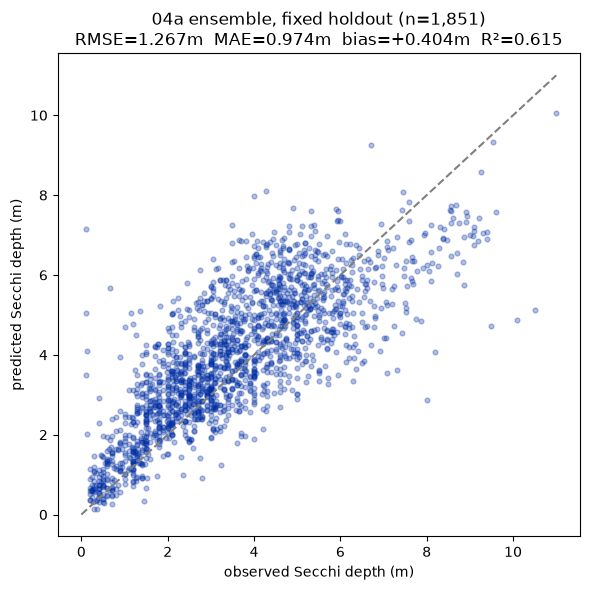

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ensemble_pred["y"], ensemble_pred["pred"], alpha=0.3, s=12, color=ROSS_LT_PAL[0])
lims = [0, max(ensemble_pred["y"].max(), ensemble_pred["pred"].max())]
ax.plot(lims, lims, ls="--", color="grey")
ax.set_xlabel("observed Secchi depth (m)")
ax.set_ylabel("predicted Secchi depth (m)")
ax.set_title(f"04a ensemble, fixed holdout (n={len(ensemble_pred):,})\n"
             f"RMSE={ensemble_metrics['rmse']:.3f}m  MAE={ensemble_metrics['mae']:.3f}m  "
             f"bias={ensemble_metrics['bias']:+.3f}m  R\u00b2={ensemble_metrics['r2']:.3f}")
plt.tight_layout()
plt.show()

## Performance by HUC8

Reported at the HUC8 level, the split's actual unit (see `05_evaluate_ensemble.ipynb`), directly comparable row-for-row against that notebook's HUC8 table.

In [4]:
huc8_metrics = (ensemble_pred.groupby("HUC8")
                .apply(lambda g: pd.Series({**M.all_metrics(g["y"], g["pred"]), "HUC4": g["HUC4"].iloc[0]}),
                       include_groups=False)
                .reset_index()
                .sort_values("rmse", ascending=False))
huc8_metrics

/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,HUC8,rmse,mae,mape,bias,p_bias,smape,r2,n,HUC4
3,10040104,1.819028,1.369710,2.006046,1.111192,38.370685,0.427627,0.118734,133,1004
25,17010101,1.635025,1.305970,0.353842,0.392378,8.583810,0.288860,0.364823,70,1701
19,14070005,1.383294,0.968642,0.275079,-0.764094,-18.956382,0.279269,0.817993,25,1407
8,10180005,1.380728,1.238868,0.617188,-0.159533,-7.363059,0.568194,0.015133,3,1018
22,16020304,1.337376,1.121039,0.922151,1.121039,76.929852,0.577488,0.796091,18,1602
26,17010203,1.329817,1.093964,0.230521,0.283544,5.371379,0.206972,0.300559,508,1701
21,16020203,1.283900,1.015786,0.417332,0.567769,17.945478,0.314543,0.289010,550,1602
0,10020001,1.217357,0.948248,0.409712,0.563578,21.951725,0.338904,0.586056,34,1002
20,14080101,1.157459,0.855970,0.252875,-0.012701,-0.351117,0.237584,0.641797,117,1408
14,13020102,1.075516,0.764979,0.975960,0.089362,6.127666,0.492612,0.434664,12,1302


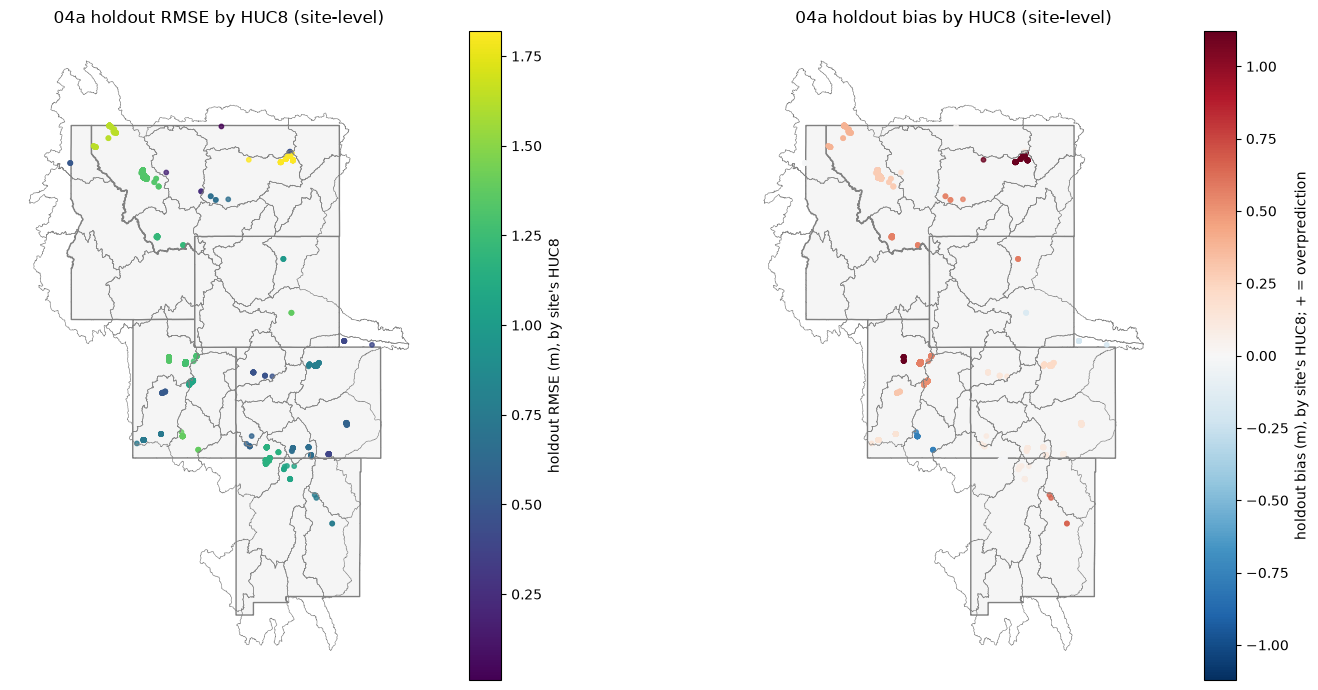

In [5]:
states = gpd.read_file(AQUAMATCH_DIR / "states.gdb", layer="states")
huc4s = gpd.read_file(AQUAMATCH_DIR / "huc4_filtered.gdb", layer="huc4_filtered")

latlon_lookup = df[["siteSR_id", "date", "lat", "lon"]].drop_duplicates(subset=["siteSR_id", "date"])
site_metrics = (ensemble_pred.merge(latlon_lookup, on=["siteSR_id", "date"], how="left")
                .merge(huc8_metrics[["HUC8", "rmse", "bias"]], on="HUC8", how="left"))
site_gdf = gpd.GeoDataFrame(site_metrics, geometry=gpd.points_from_xy(site_metrics.lon, site_metrics.lat),
                            crs="EPSG:4326").to_crs(huc4s.crs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc4s.boundary.plot(ax=ax, color="grey", linewidth=0.4)
site_gdf.plot(ax=ax, column="rmse", cmap="viridis", legend=True, markersize=10, alpha=0.8,
              legend_kwds={"label": "holdout RMSE (m), by site's HUC8"})
ax.set_title("04a holdout RMSE by HUC8 (site-level)")
ax.set_axis_off()

ax = axes[1]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc4s.boundary.plot(ax=ax, color="grey", linewidth=0.4)
vmax = site_gdf["bias"].abs().max()
site_gdf.plot(ax=ax, column="bias", cmap="RdBu_r", vmin=-vmax, vmax=vmax, legend=True, markersize=10, alpha=0.8,
              legend_kwds={"label": "holdout bias (m), by site's HUC8; + = overprediction"})
ax.set_title("04a holdout bias by HUC8 (site-level)")
ax.set_axis_off()

fig.tight_layout()
plt.show()

### Predicted vs. observed in the worst-performing HUC8s

Small multiples for the worst-RMSE HUC8s (restricted to `n >= 15` so this isn't dominated by tiny, noisy groups), each panel on its own 1:1 line — same basins/panels as `05`'s equivalent plot, for direct comparison.

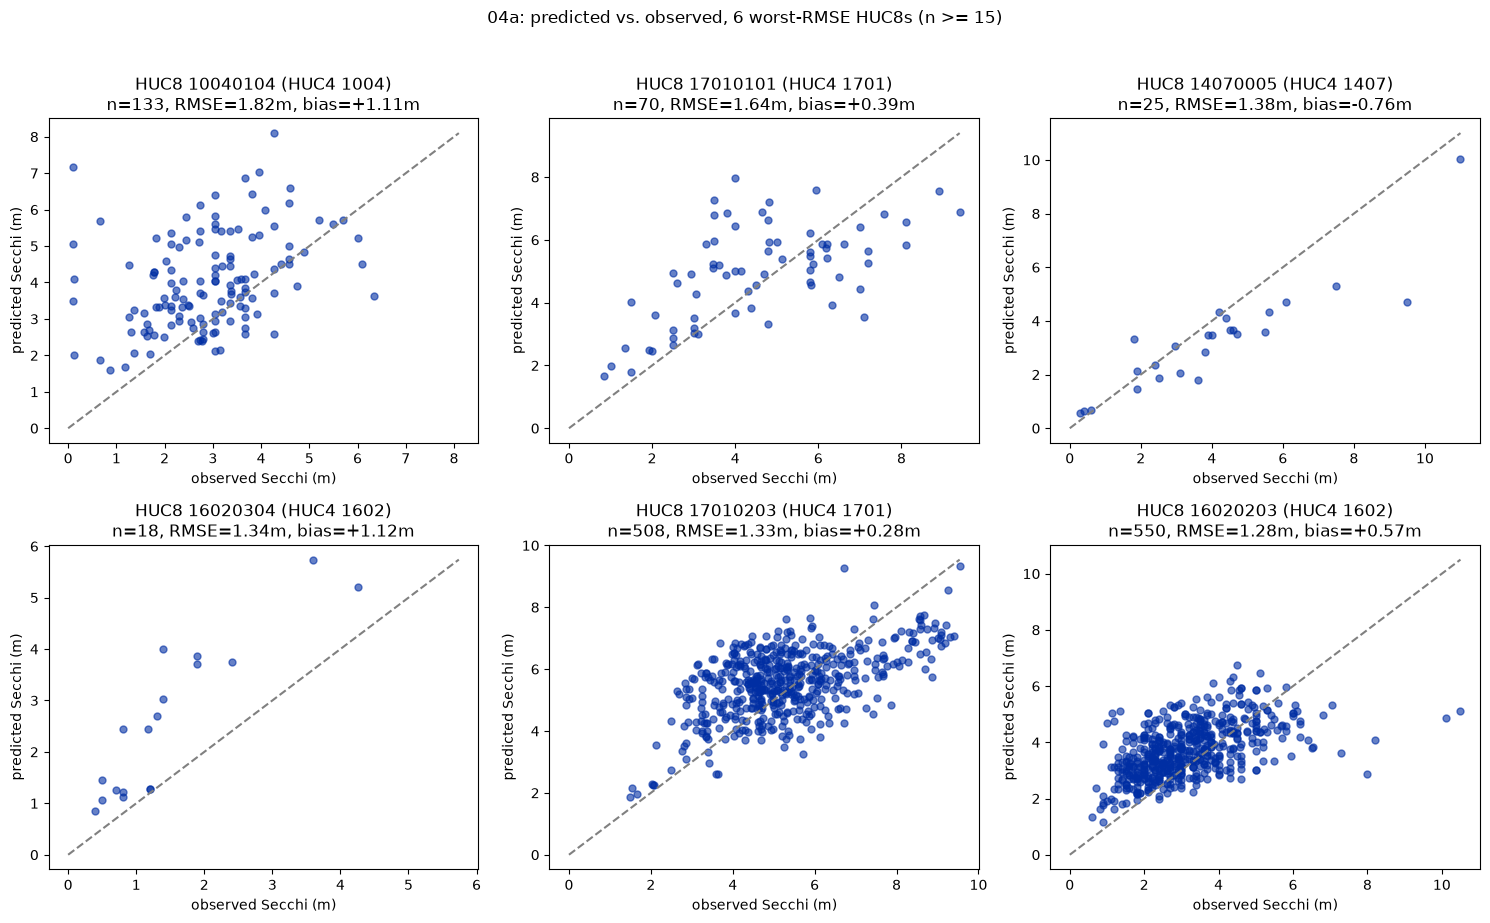

In [6]:
N_WORST = 6
MIN_N = 15
worst_huc8 = huc8_metrics[huc8_metrics["n"] >= MIN_N].sort_values("rmse", ascending=False).head(N_WORST)

n_panels = len(worst_huc8)
ncols = 3
nrows = -(-n_panels // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for ax, (_, row) in zip(axes.flat, worst_huc8.iterrows()):
    sub = ensemble_pred[ensemble_pred["HUC8"] == row["HUC8"]]
    ax.scatter(sub["y"], sub["pred"], alpha=0.6, s=25, color=ROSS_LT_PAL[0])
    lims = [0, max(sub["y"].max(), sub["pred"].max())]
    ax.plot(lims, lims, ls="--", color="grey")
    ax.set_title(f"HUC8 {row['HUC8']} (HUC4 {row['HUC4']})\n"
                 f"n={int(row['n'])}, RMSE={row['rmse']:.2f}m, bias={row['bias']:+.2f}m")
    ax.set_xlabel("observed Secchi (m)")
    ax.set_ylabel("predicted Secchi (m)")

for ax in axes.flat[n_panels:]:
    ax.set_visible(False)

fig.suptitle(f"04a: predicted vs. observed, {N_WORST} worst-RMSE HUC8s (n >= {MIN_N})", y=1.02)
fig.tight_layout()
plt.show()

## Seed-to-seed spread

The motivating question for `04a` was whether seeds capture more useful variability than model architecture. Here, with only one architecture, all remaining spread across the 10 arms is seed-driven by construction — this just quantifies how much of it there is, for comparison against the production ensemble's seed-vs-architecture decomposition (seed ~65%, architecture ~13%, from the exploratory analysis that motivated this notebook).

04a: typical per-point std across the 10 seeds: 0.1087m (median 0.0934m)
04a: seed-vs-seed pairwise corr: mean=0.9955, min=0.9913, max=0.9983


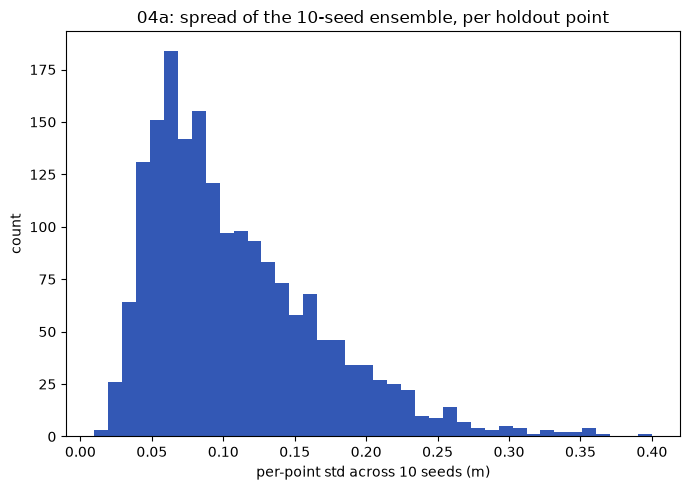

In [7]:
pivot = all_preds.pivot_table(index=["siteSR_id", "date"], columns="seed", values="pred")
per_point_std = pivot.std(axis=1)
print(f"04a: typical per-point std across the 10 seeds: {per_point_std.mean():.4f}m "
      f"(median {per_point_std.median():.4f}m)")

seed_corrs = []
for i, s1 in enumerate(pivot.columns):
    for s2 in pivot.columns[i + 1:]:
        seed_corrs.append(np.corrcoef(pivot[s1], pivot[s2])[0, 1])
print(f"04a: seed-vs-seed pairwise corr: mean={np.mean(seed_corrs):.4f}, "
      f"min={np.min(seed_corrs):.4f}, max={np.max(seed_corrs):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(per_point_std, bins=40, color=ROSS_LT_PAL[0], alpha=0.8)
ax.set_xlabel("per-point std across 10 seeds (m)")
ax.set_ylabel("count")
ax.set_title("04a: spread of the 10-seed ensemble, per holdout point")
plt.tight_layout()
plt.show()

## SHAP feature attribution

Same approach as `05_evaluate_ensemble.ipynb`: each seed's own final feature set and gap-aware-tuned hyperparameters are reused unchanged (no re-selection/re-tuning), retrained on that seed's 4 folds, and explained with `shap.TreeExplainer` on the shared holdout. Restricted to the **unanimous core** — features present in all 10 seeds' own final sets.

In [8]:
def load_seed_config(seed):
    with open(MODELS_DIR / f"seed{seed}" / "backward_elim_summary.json") as fh:
        feats = json.load(fh)["final_features"]
    with open(MODELS_DIR / f"seed{seed}" / "final_tune_xgboost.json") as fh:
        params = json.load(fh)["best_params"]
    return feats, params


per_seed = {}
for seed in SEEDS:
    folds = spatial_cv.build_folds(df, seed)
    feats, params = load_seed_config(seed)
    print(f"seed{seed}: training 4 folds + SHAP on {len(holdout)}-row holdout ({len(feats)} feats)")
    fold_shaps = []
    for f in folds:
        model = MOD.train_fold_models([f], feats, TARGET, params)[0]
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(xgb.DMatrix(holdout[feats]))
        fold_shaps.append(np.asarray(sv))
    mean_shap = np.mean(fold_shaps, axis=0)
    per_seed[seed] = pd.DataFrame(mean_shap, columns=feats)

unanimous = None
for feats_df in per_seed.values():
    cols = set(feats_df.columns)
    unanimous = cols if unanimous is None else (unanimous & cols)
unanimous = sorted(unanimous)
print(f"\nunanimous core ({len(unanimous)} features): {unanimous}")

seed601: training 4 folds + SHAP on 2218-row holdout (27 feats)


seed602: training 4 folds + SHAP on 2218-row holdout (32 feats)


seed603: training 4 folds + SHAP on 2218-row holdout (28 feats)


seed604: training 4 folds + SHAP on 2218-row holdout (26 feats)


seed605: training 4 folds + SHAP on 2218-row holdout (32 feats)


...

seed607: training 4 folds + SHAP on 2218-row holdout (30 feats)


seed608: training 4 folds + SHAP on 2218-row holdout (29 feats)


seed609: training 4 folds + SHAP on 2218-row holdout (24 feats)


seed610: training 4 folds + SHAP on 2218-row holdout (29 feats)



unanimous core (22 features): ['BG', 'BR', 'MNDWI', 'NDSSI', 'NDVI', 'NR', 'atm_corr_LaSRC', 'catchment_area_sqkm', 'fai', 'green_corr7', 'nir_corr7', 'pct_cropland_2006', 'pct_forest_2006', 'pct_impervious_2006', 'pct_wetland_2006', 'shore_flag', 'srad_Wm2_prev1', 'srad_Wm2_prev30', 'temp_corr7', 'tmax_degC_prev30', 'tmean_degC_prev30', 'tmin_degC_prev30']


top 8 features by mean|SHAP|:
BG                     0.5046
green_corr7            0.4712
BR                     0.3365
fai                    0.2193
MNDWI                  0.2086
catchment_area_sqkm    0.1891
NR                     0.1634
NDVI                   0.0978
dtype: float32

share of total mean|SHAP| attribution by category:
optical    76.300003
site       17.200001
weather     6.500000
dtype: float32


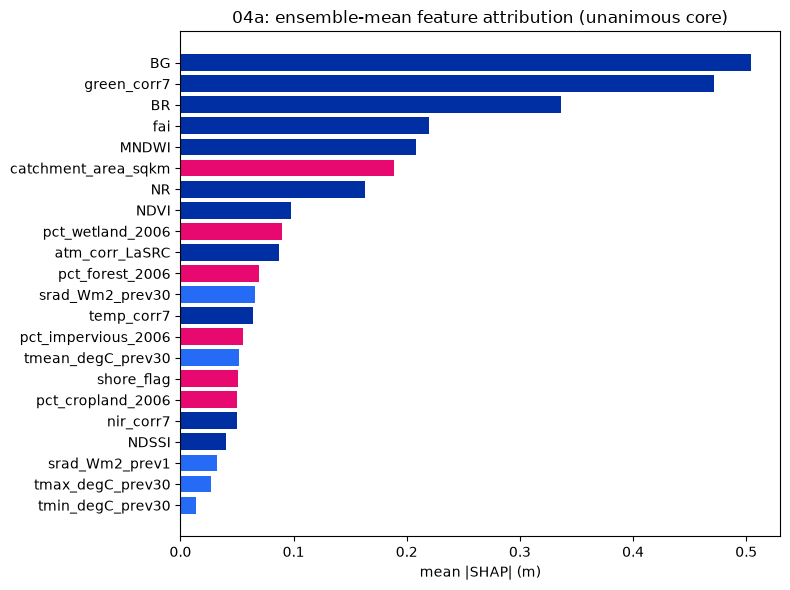

In [9]:
long_rows = []
for seed, feats_df in per_seed.items():
    sub = feats_df[unanimous].copy()
    sub["seed"] = seed
    sub["_row"] = np.arange(len(holdout))
    long_rows.append(sub)
long_df = pd.concat(long_rows, ignore_index=True)

ensemble_mean_shap = long_df.groupby("_row")[unanimous].mean().sort_index()

SITE_COLS = {"elevation_m", "catchment_area_sqkm", "pct_impervious_2006", "pct_urban_2006",
             "pct_forest_2006", "pct_cropland_2006", "pct_wetland_2006", "shore_flag"}
WEATHER_PREFIXES = ("precip_mm_prev", "tmax_degC_prev", "tmean_degC_prev", "tmin_degC_prev", "srad_Wm2_prev")


def categorize(feat):
    if feat in SITE_COLS:
        return "site"
    if feat.startswith(WEATHER_PREFIXES):
        return "weather"
    return "optical"


mean_abs_shap = ensemble_mean_shap.abs().mean().sort_values(ascending=False)
cat_share = mean_abs_shap.groupby(categorize).sum() / mean_abs_shap.sum() * 100
print("top 8 features by mean|SHAP|:")
print(mean_abs_shap.head(8).round(4))
print("\nshare of total mean|SHAP| attribution by category:")
print(cat_share.round(1))

fig, ax = plt.subplots(figsize=(8, 6))
colors = mean_abs_shap.index.map(lambda f: {"optical": ROSS_LT_PAL[0], "site": ROSS_LT_PAL[1],
                                             "weather": ROSS_LT_PAL[2]}[categorize(f)])
ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1], color=colors[::-1])
ax.set_xlabel("mean |SHAP| (m)")
ax.set_title("04a: ensemble-mean feature attribution (unanimous core)")
plt.tight_layout()
plt.show()

## Per-HUC8 SHAP

catchment_area_sqkm mean|SHAP| by HUC8 (top 5):
HUC8
10040104    0.5146
17010305    0.3484
14070005    0.3381
17010203    0.3275
16030006    0.2828
Name: catchment_area_sqkm, dtype: float32


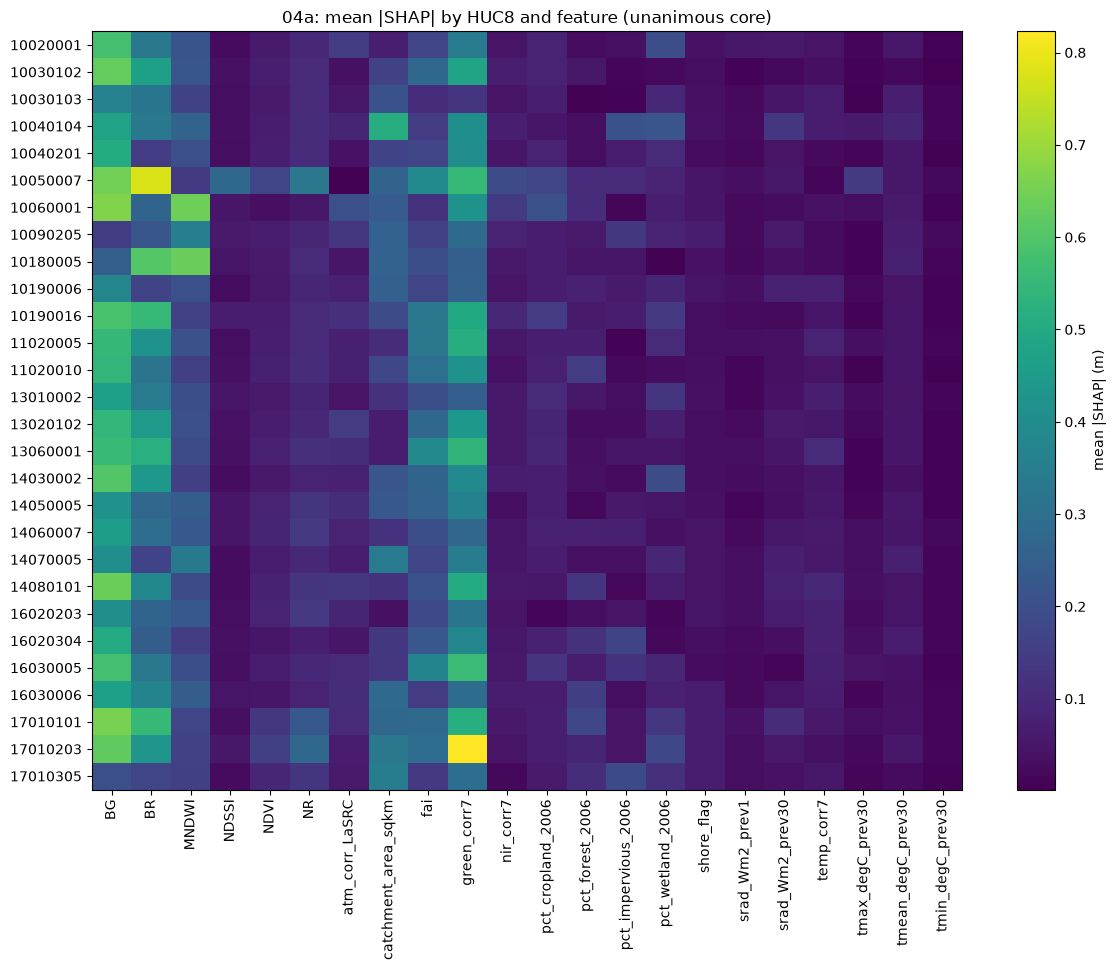

In [10]:
shap_with_huc8 = ensemble_mean_shap.copy()
shap_with_huc8["HUC8"] = holdout["HUC8"].values
huc8_shap = shap_with_huc8.groupby("HUC8")[unanimous].apply(lambda g: g.abs().mean())

if "catchment_area_sqkm" in huc8_shap.columns:
    print("catchment_area_sqkm mean|SHAP| by HUC8 (top 5):")
    print(huc8_shap["catchment_area_sqkm"].sort_values(ascending=False).head(5).round(4))

fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(huc8_shap))))
im = ax.imshow(huc8_shap.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(unanimous)))
ax.set_xticklabels(unanimous, rotation=90)
ax.set_yticks(range(len(huc8_shap)))
ax.set_yticklabels(huc8_shap.index)
ax.set_title("04a: mean |SHAP| by HUC8 and feature (unanimous core)")
fig.colorbar(im, ax=ax, label="mean |SHAP| (m)")
plt.tight_layout()
plt.show()

## Summary

**10 seeds x XGBoost matches — marginally beats — 5 seeds x XGBoost+LightGBM, at the same 40-model count.** Holdout RMSE 1.267m vs. 1.271m, MAE 0.974m vs. 0.979m, R² 0.615 vs. 0.610, bias +0.404m vs. +0.400m (both configurations carry essentially the same overprediction bias — see `05`'s note that this is real and unresolved, not something either configuration fixes). The differences are small enough to be within run-to-run noise, not a clear win either way, but they're enough to say confidently that dropping the second algorithm **costs nothing**.

**This confirms the variance-decomposition finding that motivated the experiment.** Seed-to-seed pairwise correlation here (mean 0.9955) is close to what the production ensemble showed within a single algorithm (~0.994), and the typical per-point spread across these 10 seeds (0.109m) is in the same range as production's seed-driven spread (~0.103m) — consistent with seed, not algorithm, being where this ensemble's useful diversity actually comes from.

**Feature attribution is essentially unchanged.** 22 features are unanimous across all 10 seeds (vs. 20 for the 5-seed x 2-algorithm production core) — a larger unanimous set is expected with only one algorithm's idiosyncrasies to agree across, not two. The same optical ratios dominate (`BG`, `green_corr7`, `BR`, `fai`), the same site/weather/optical category split holds (77/17/7% vs. production's 77/17/6%), and `catchment_area_sqkm` shows the same concentrated importance at the same hard basins (HUC 14070005/Lake Powell, HUC 17010203/17010305 in the 1701 cluster) as the production SHAP analysis found.

**For downstream applications:** given this project is still in its early phases, a single-architecture, more-seeds design is worth serious consideration going forward — it halves the modeling code path (no LightGBM-specific tuning/elimination/serving logic to maintain) for no measurable accuracy cost at equal compute, and the feature-selection/SHAP story it tells is the same one. This notebook and `04a` are the evidence for that recommendation, not a decision — the production pipeline (`04`/`05`) hasn't been changed.